In [5]:
import itertools as itt
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from common import CONTEXT_SET, evaluations_dir


## LATENT EMBEDDINGS

In [25]:
le_df = pd.read_csv(
    evaluations_dir / "EGFR_MAPK" / "dream_cytof" / "EGFR_MAPK.dream_cytof.latent_embeddings.csv"
)

### PAM50 subtypes

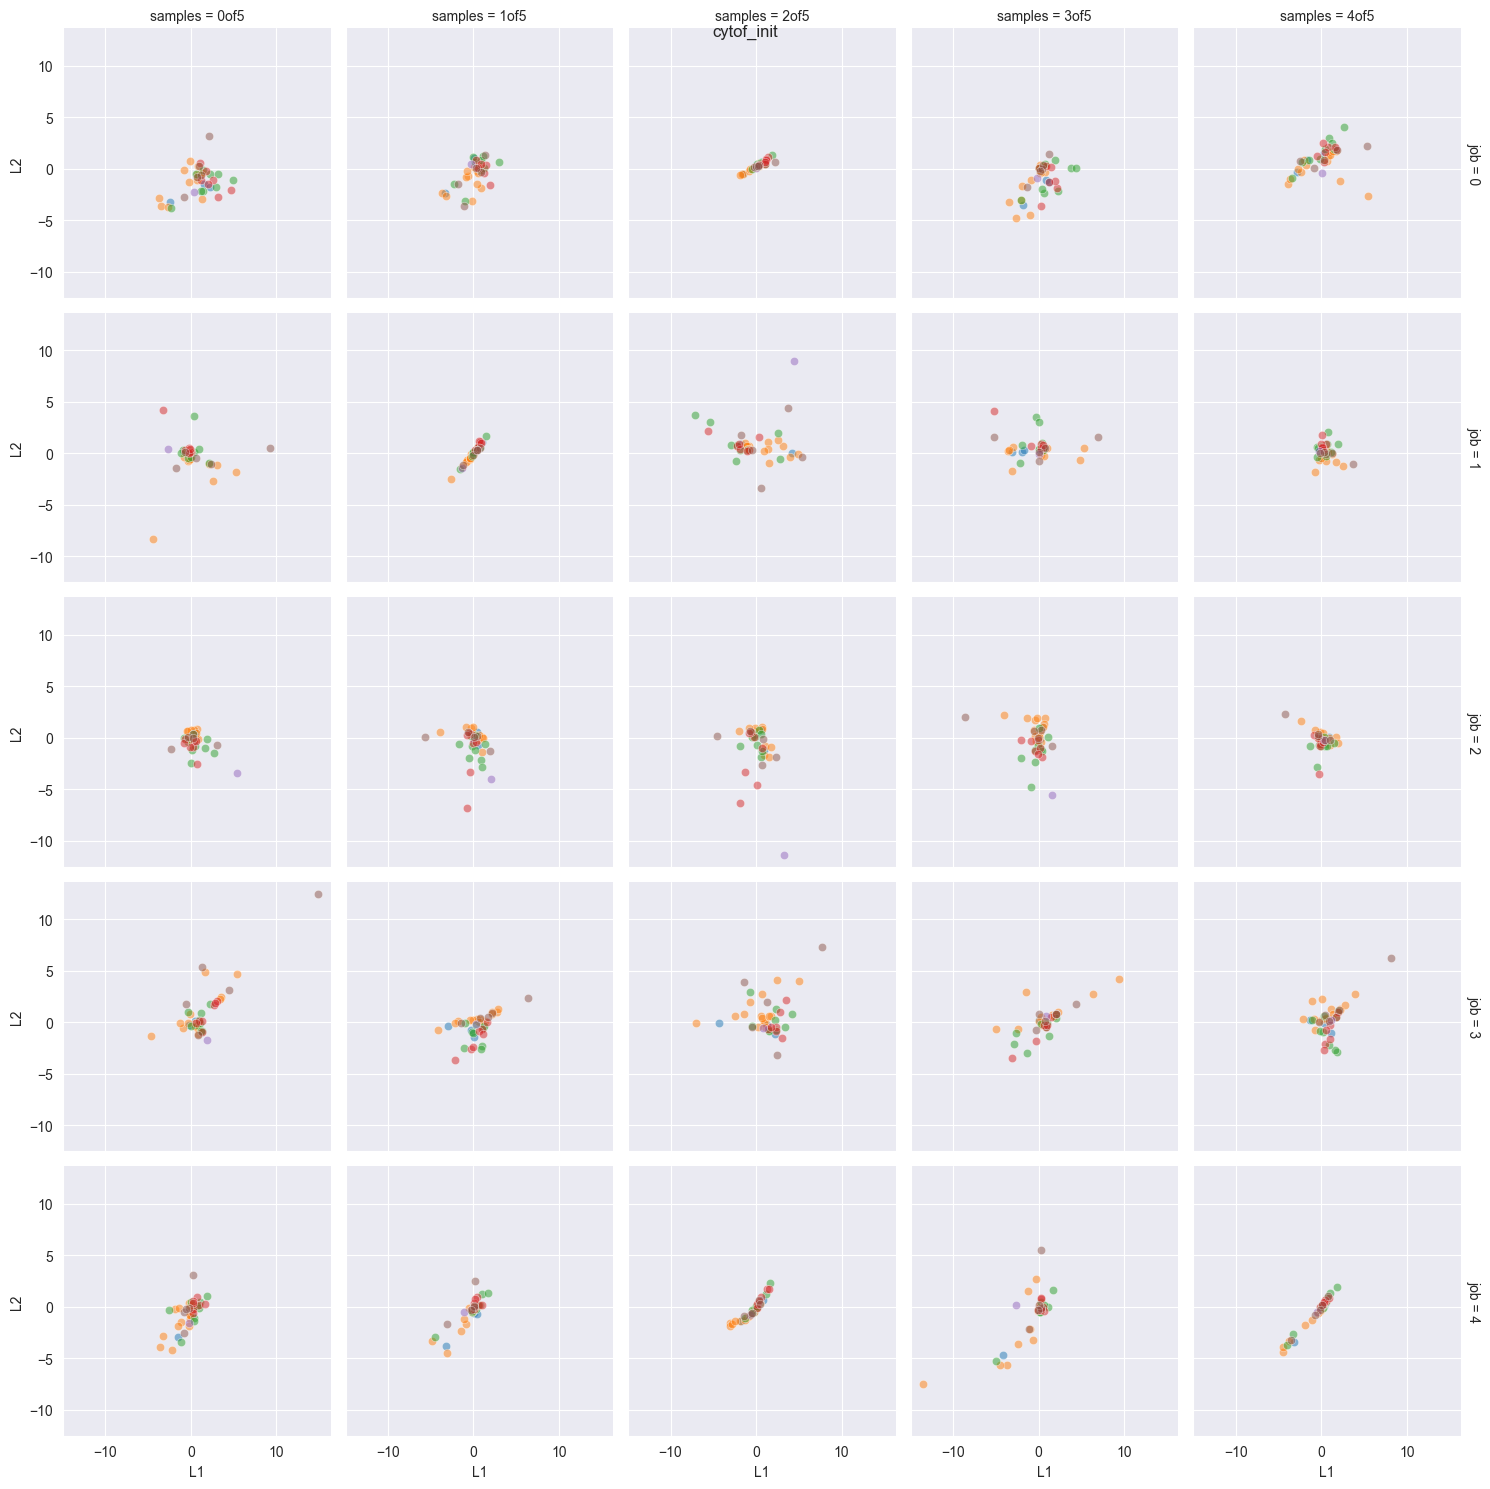

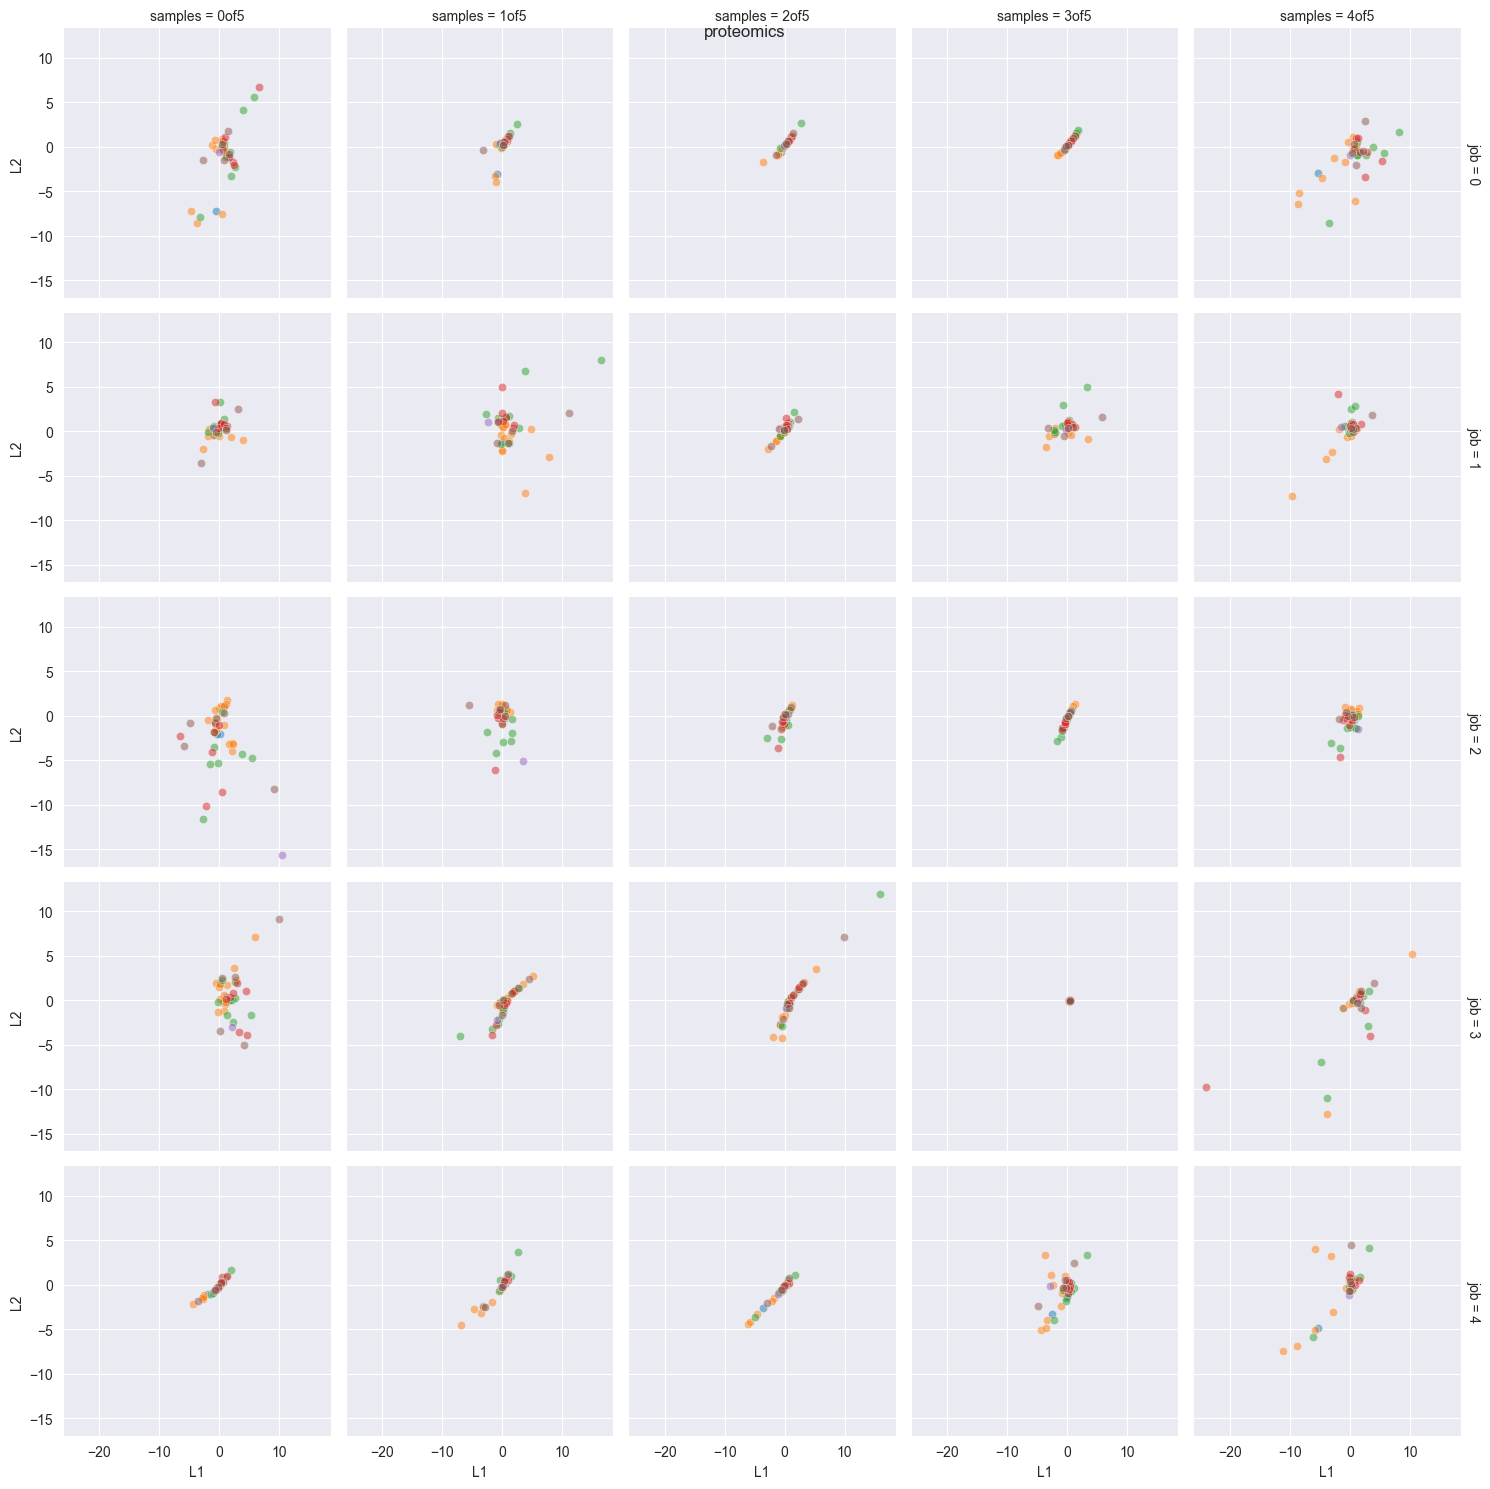

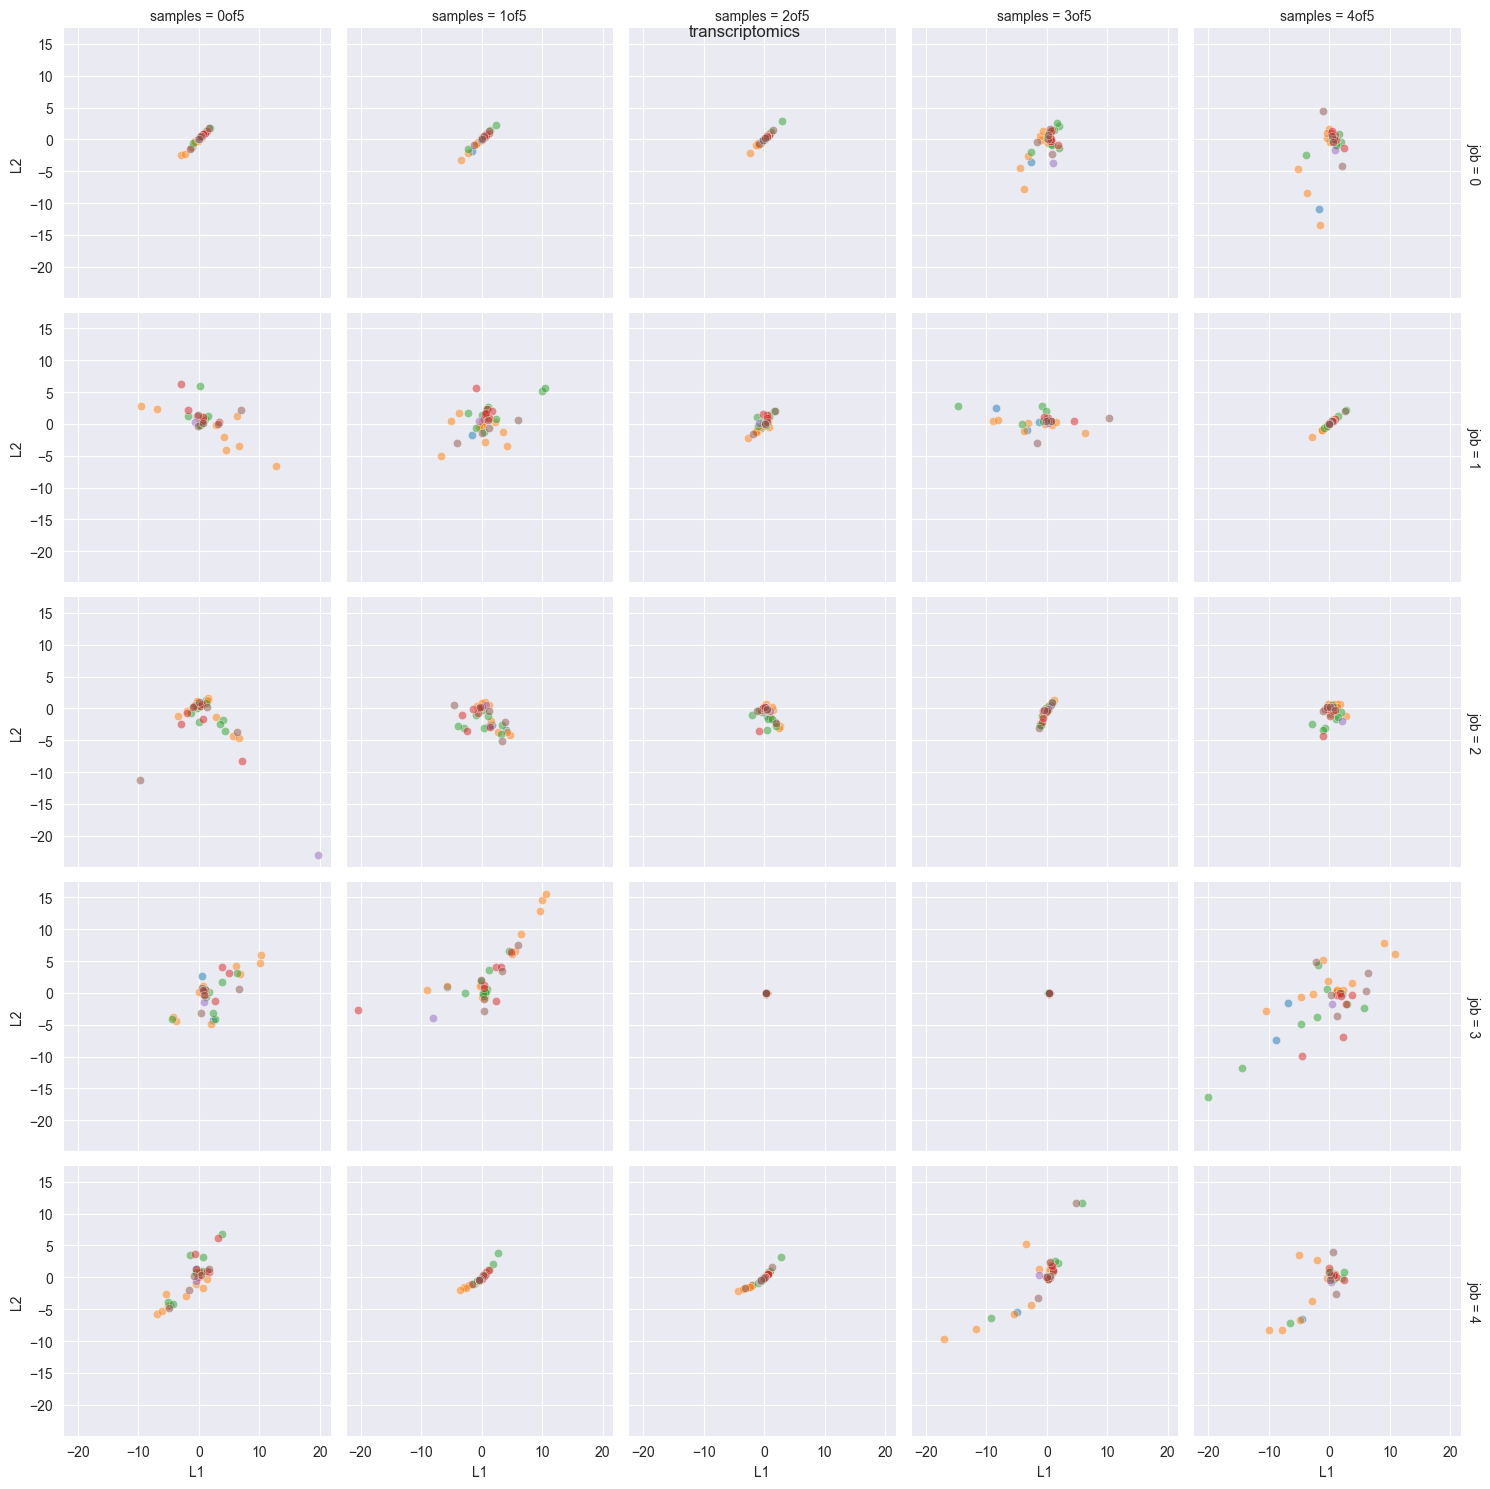

In [26]:
num_jobs = 5
for context in CONTEXT_SET:    
    g = sns.FacetGrid(le_df[le_df.context == context], row="job", col="samples", hue="subtype_PAM50", margin_titles=True)
    g.map(sns.scatterplot, "L1", "L2", alpha=0.5)
    plt.suptitle(context)
    plt.show()

### Luminal/Basal subtypes

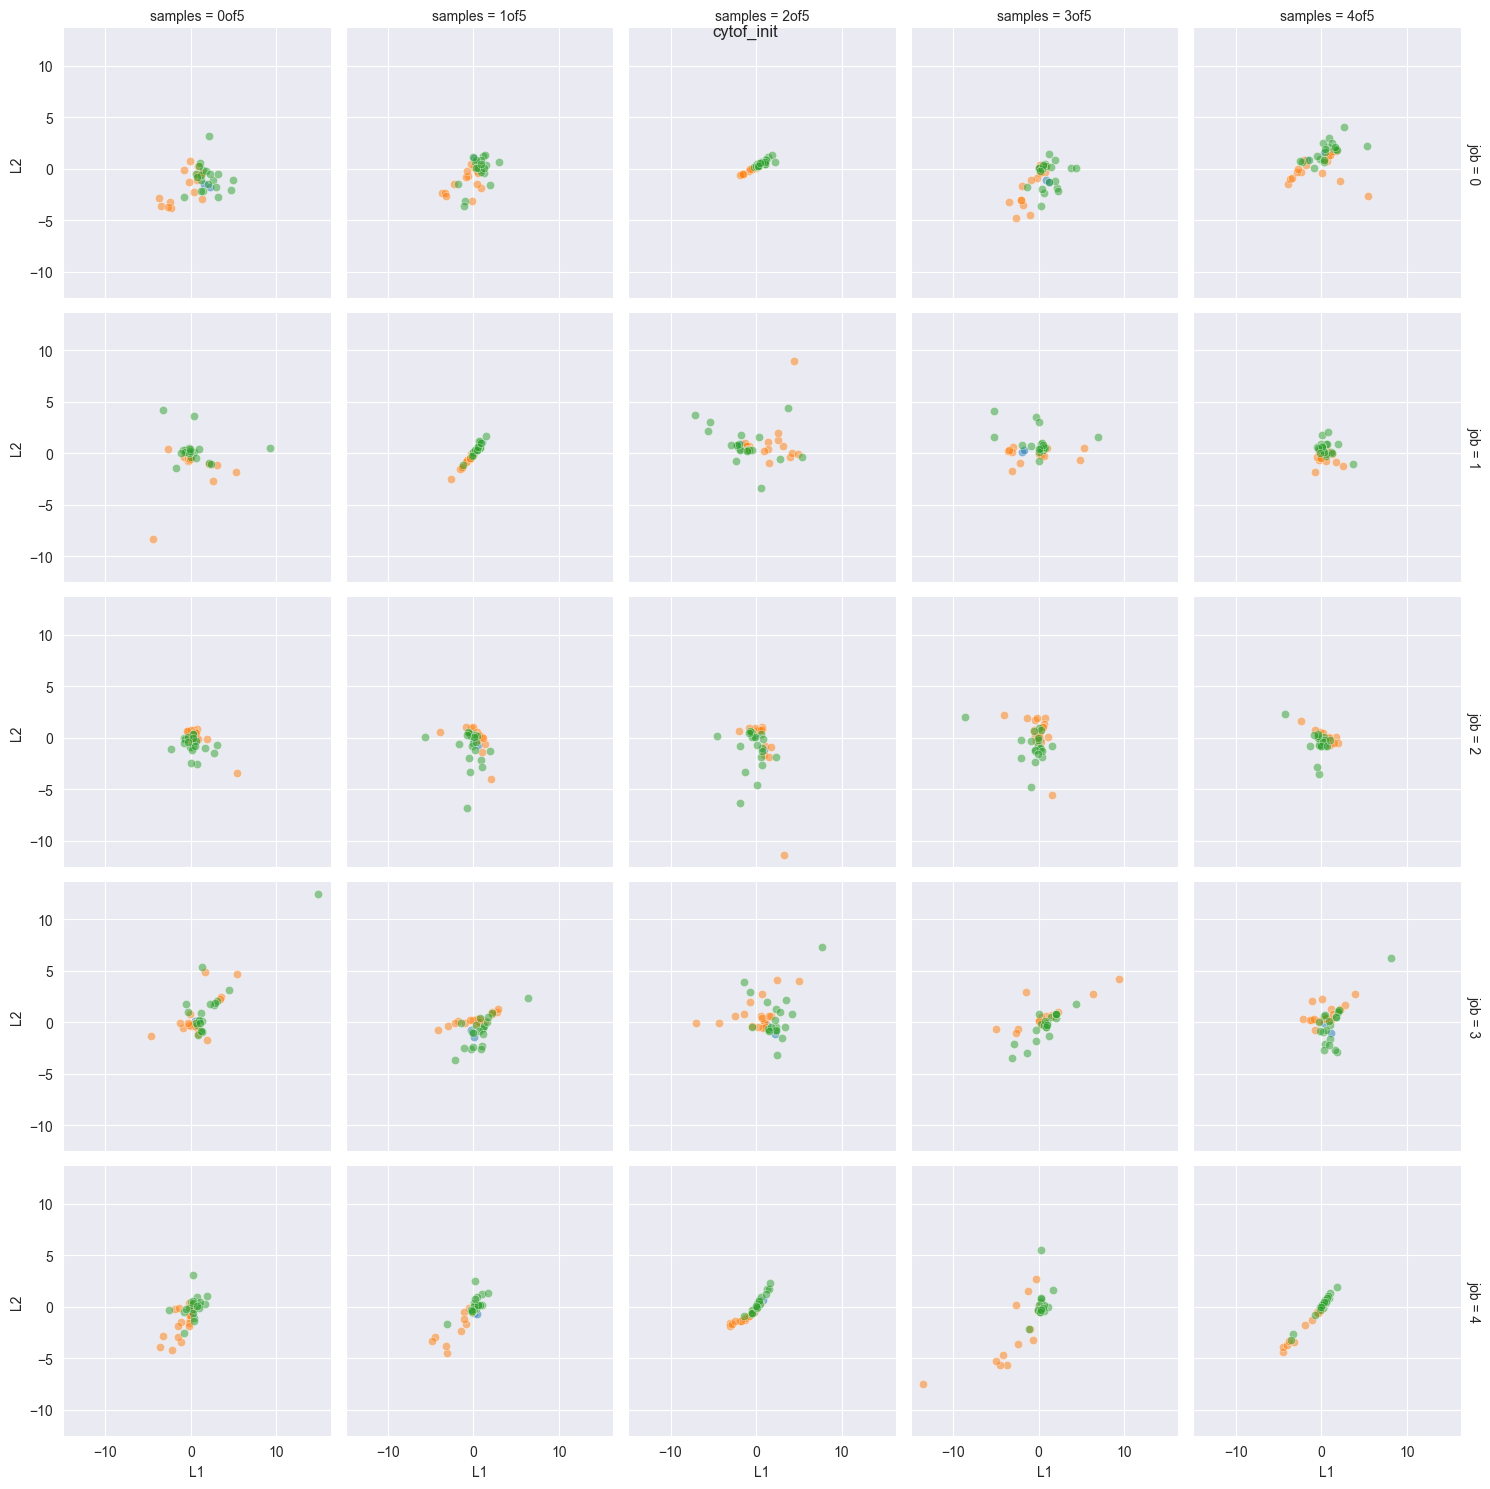

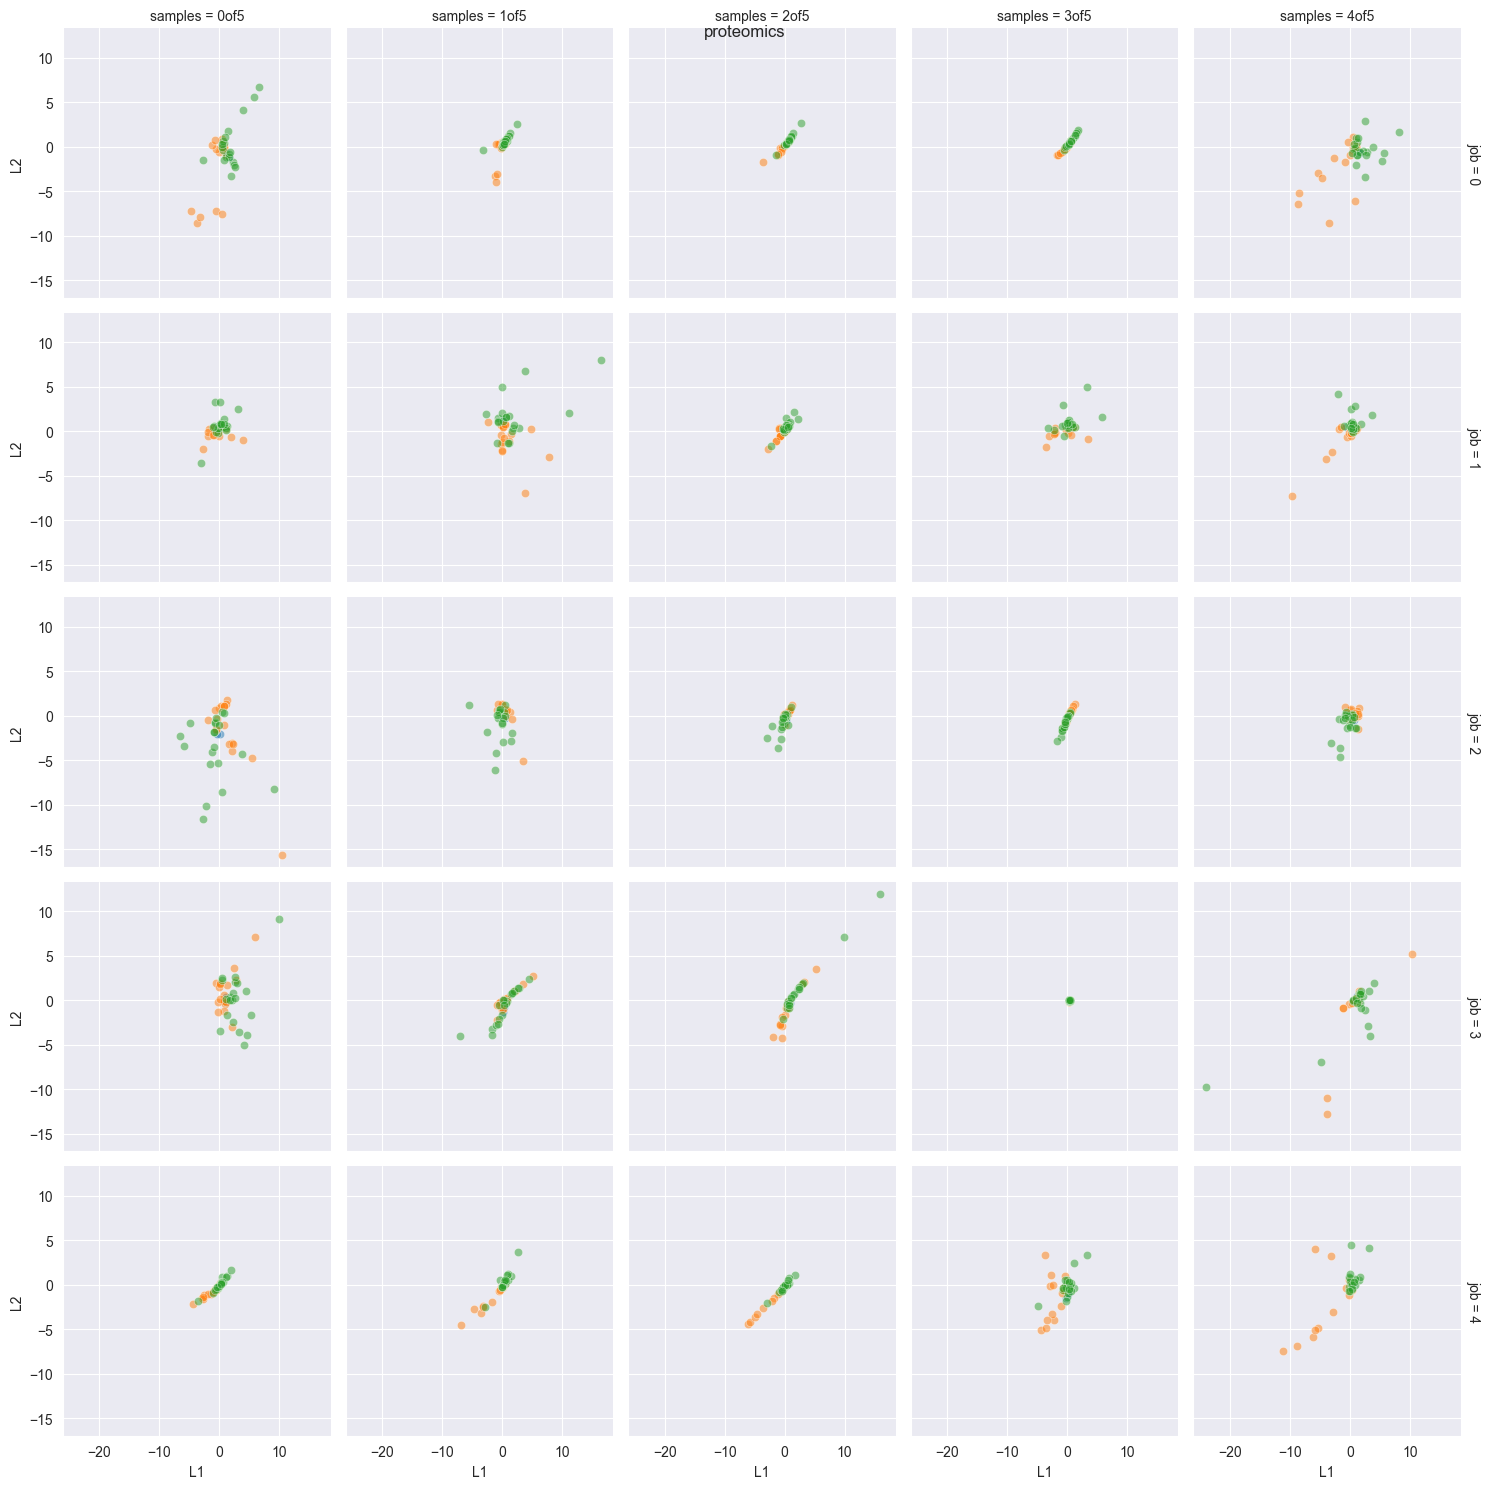

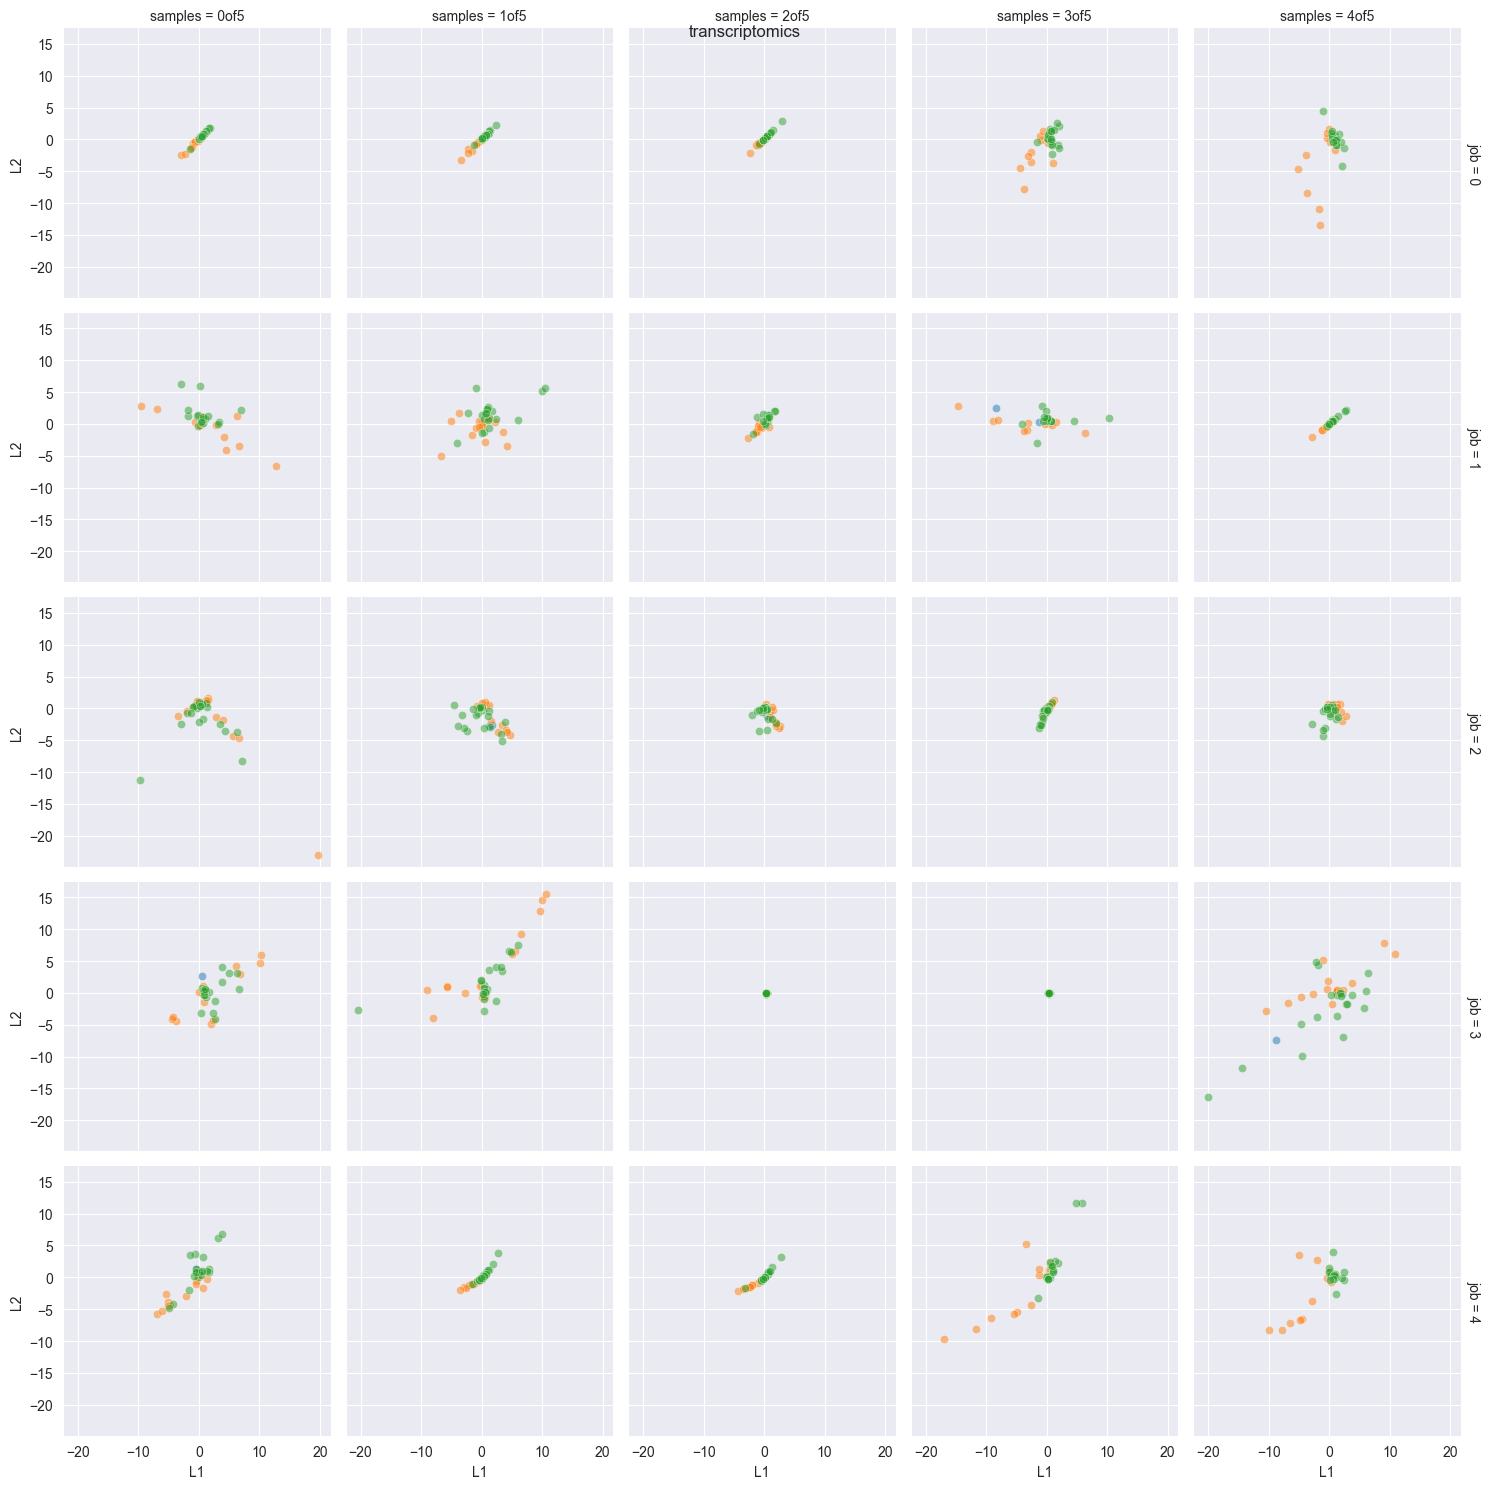

In [27]:
num_jobs = 5
for context in CONTEXT_SET:    
    g = sns.FacetGrid(le_df[le_df.context == context], row="job", col="samples", hue="subtype_Luminal/Basal", margin_titles=True)
    g.map(sns.scatterplot, "L1", "L2", alpha=0.5)
    plt.suptitle(context)
    plt.show()

## PARAMETER DEVIATIONS

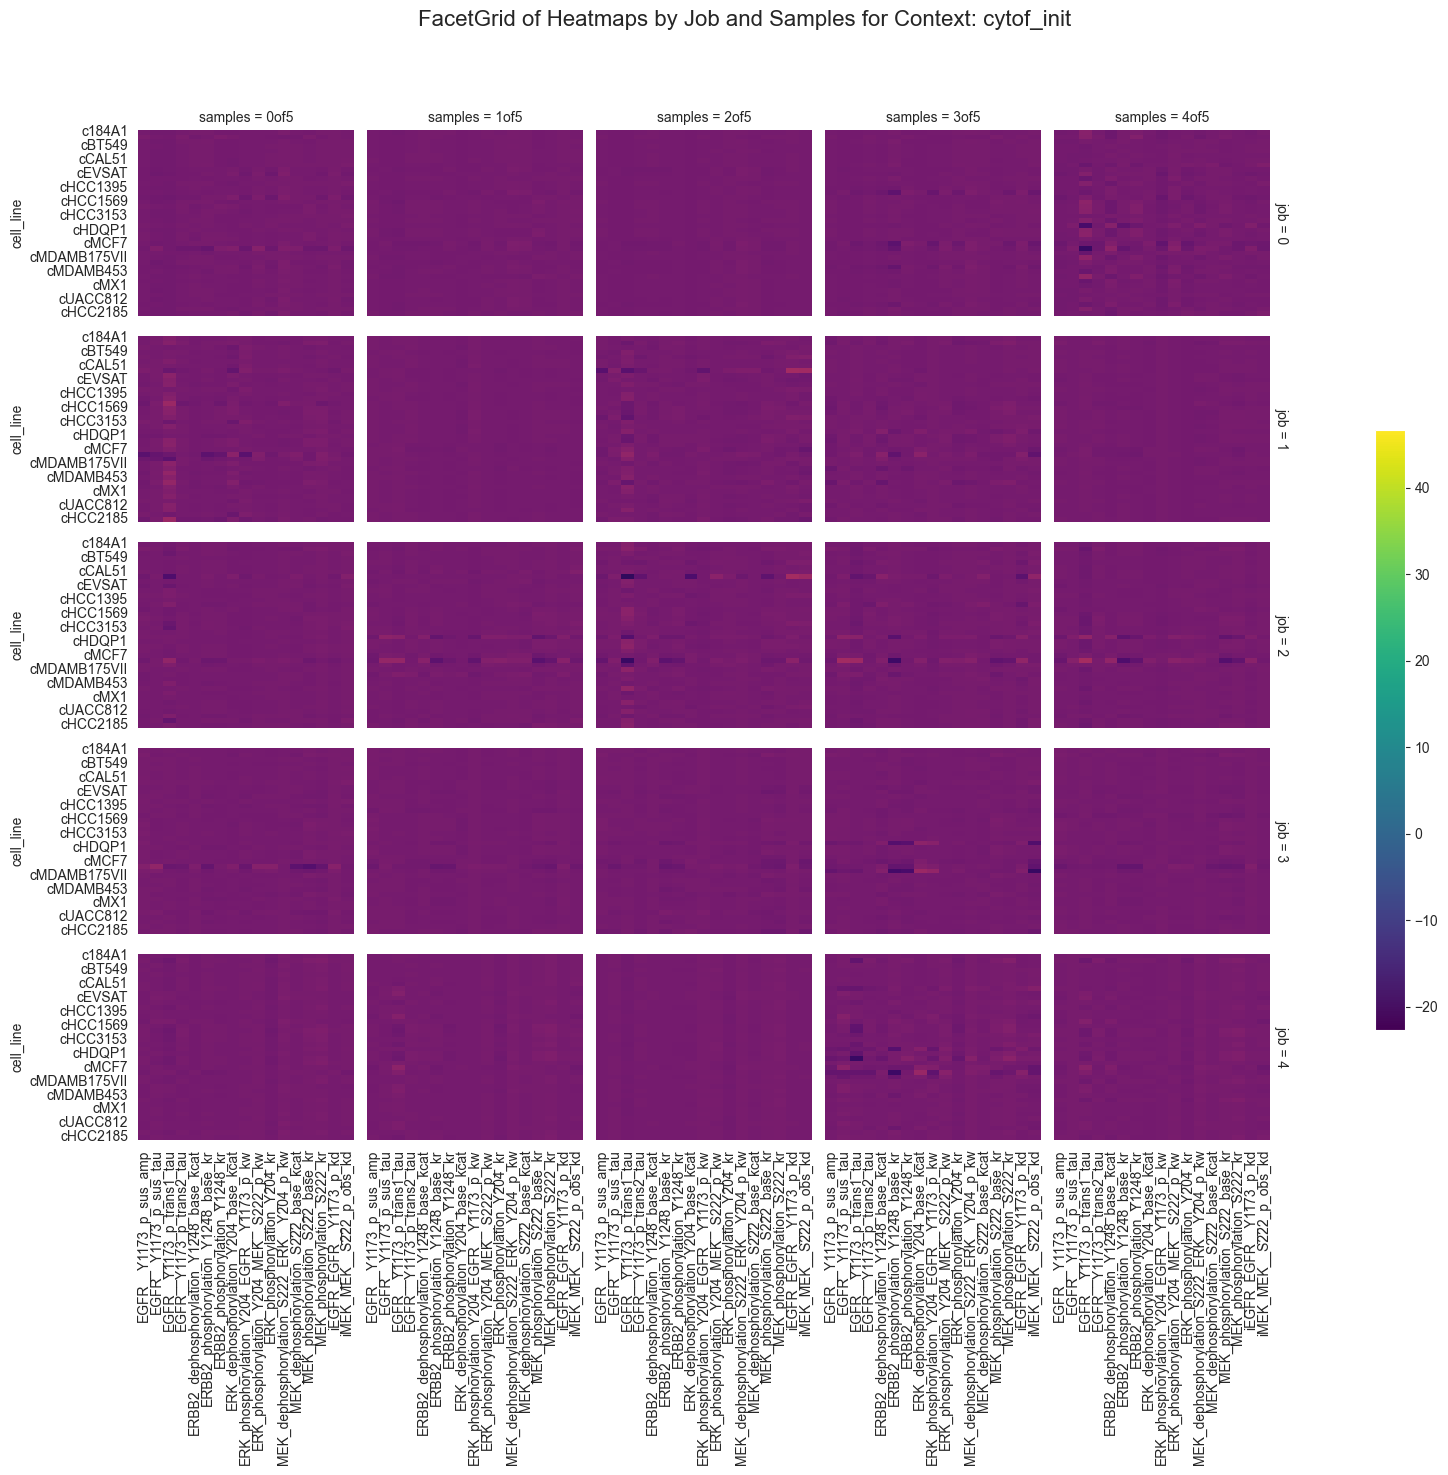

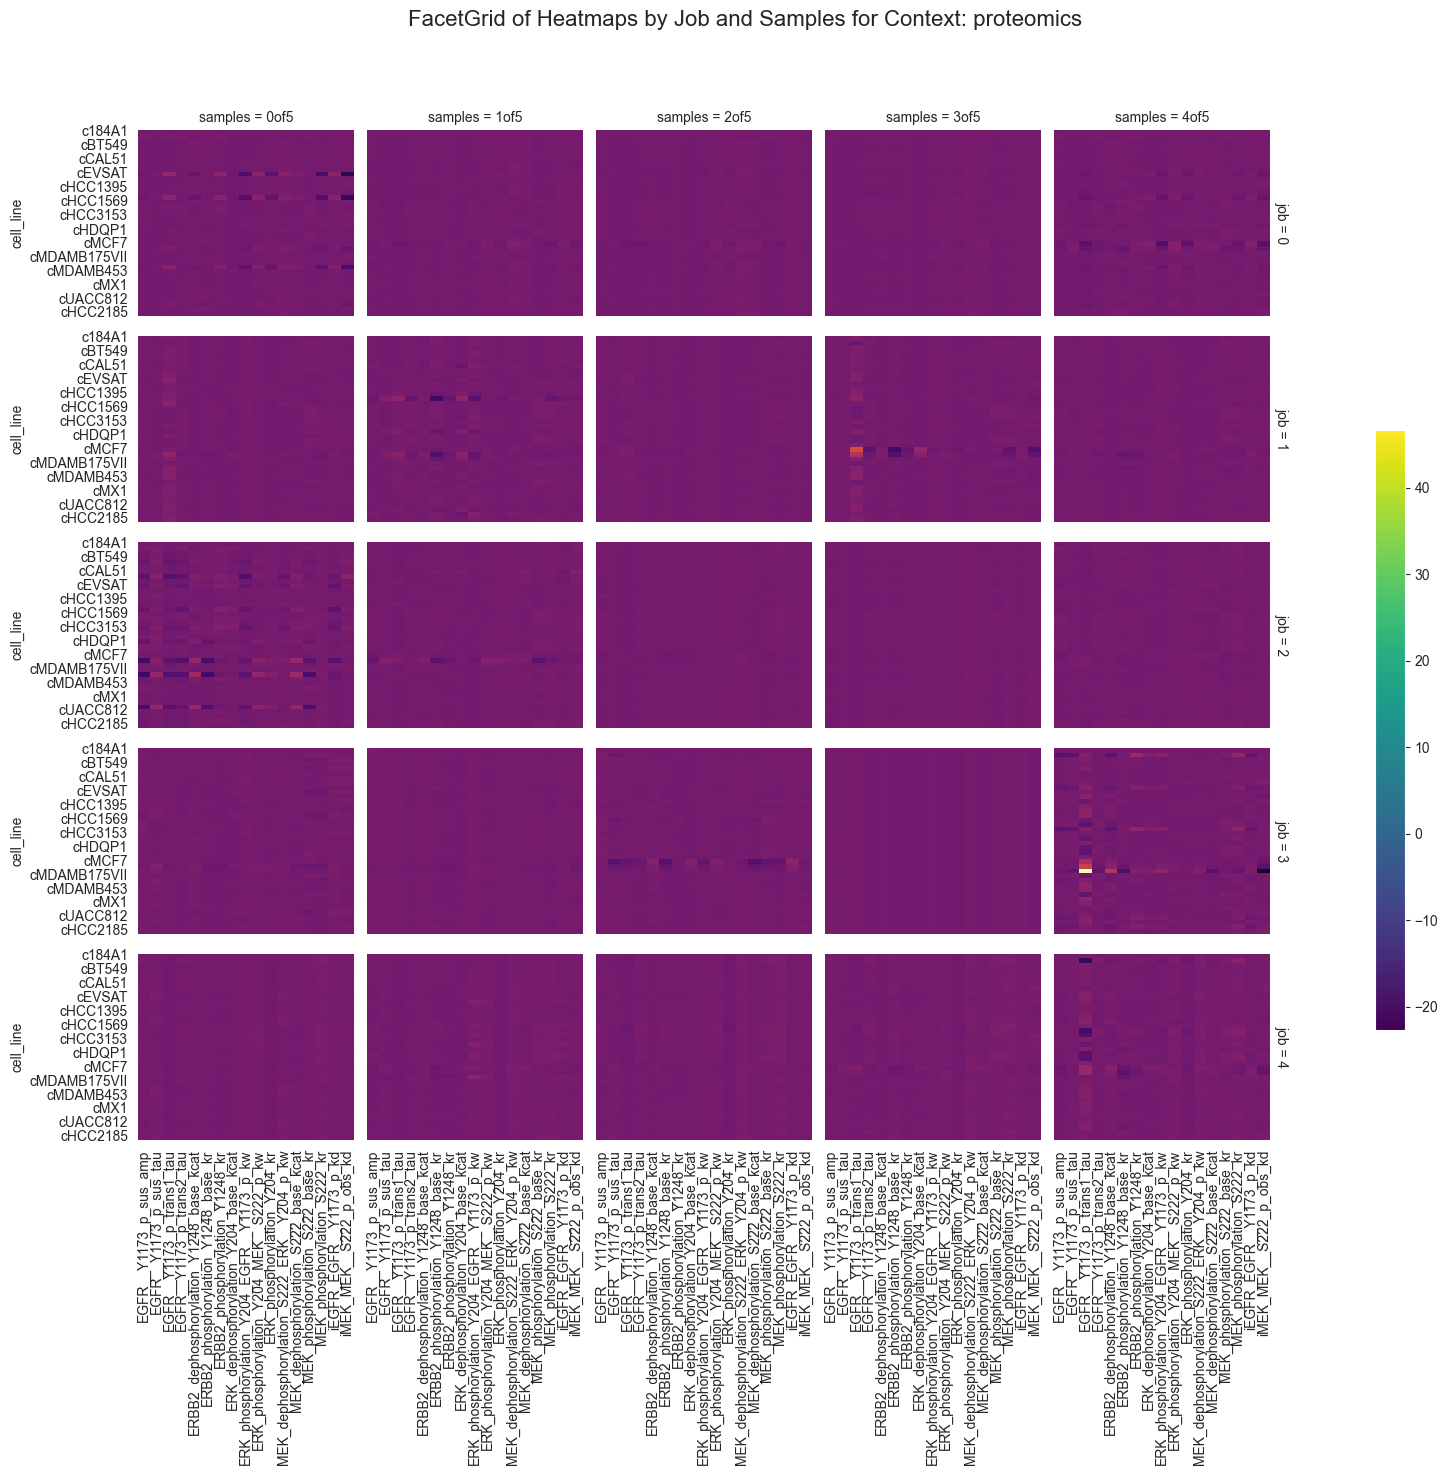

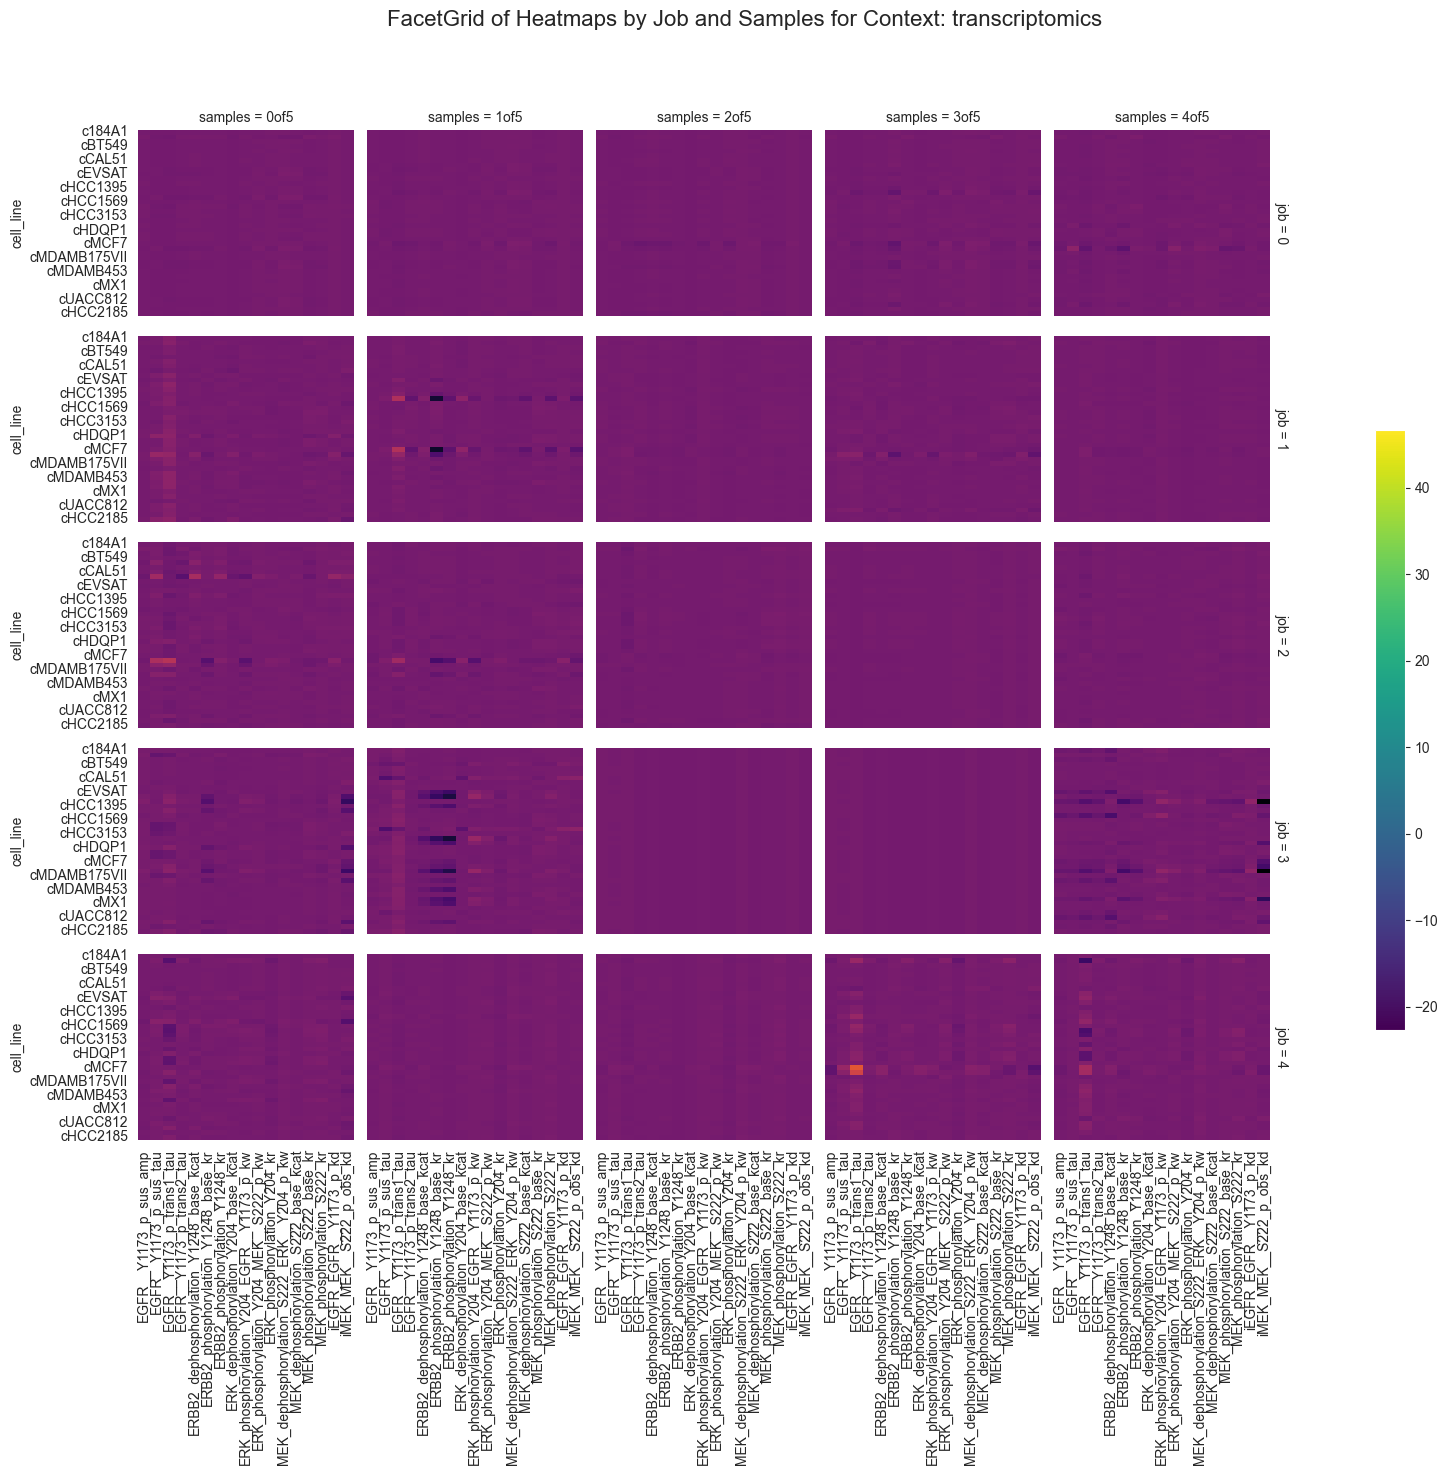

In [58]:
param_dev_df = pd.read_csv(
    evaluations_dir / "EGFR_MAPK" / "dream_cytof" / "EGFR_MAPK.dream_cytof.parameter_deviations.csv", 
    index_col="cell_line"
).drop(columns=["Unnamed: 0"])

# Ensure parameter columns are numeric
parameter_columns = param_dev_df.columns.difference(['samples', 'job', 'dataset', 'context', "subtype_PAM50", "subtype_Luminal/Basal"])

# Calculate the global vmin and vmax for the entire dataset (across all parameters)
vmin = param_dev_df[parameter_columns].min().min()  # Minimum value across all parameters
vmax = param_dev_df[parameter_columns].max().max()  # Maximum value across all parameters

# Define a function to plot a heatmap for each facet
def heatmap(data, **kwargs):
    sns.heatmap(data[parameter_columns], vmin=vmin, vmax=vmax, cbar=False, **kwargs)

# Loop through each unique context
for context in CONTEXT_SET:
    # Filter the dataframe for the current context
    param_dev_df_context = param_dev_df[param_dev_df['context'] == context]
    
    # Create a FacetGrid for the current context
    g = sns.FacetGrid(param_dev_df_context, col='samples', row='job', margin_titles=True)

    # Map the heatmap function onto the grid
    g.map_dataframe(heatmap, annot=False, cmap='inferno')

    # Add a single colorbar for the entire grid
    cbar_ax = g.fig.add_axes([.92, .3, .02, .4])  # Define the colorbar axis
    norm = plt.Normalize(vmin=vmin, vmax=vmax)  # Normalize the colorbar to the vmin and vmax
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])  # This step is necessary to set the scalar mappable correctly
    g.fig.colorbar(sm, cax=cbar_ax)  # Add the colorbar to the grid

    # Adjust layout and add a title indicating the context
    plt.subplots_adjust(top=0.9, right=0.85)  # Adjust the right side to fit the colorbar
    g.fig.suptitle(f'FacetGrid of Heatmaps by Job and Samples for Context: {context}', fontsize=16)

    # Show the plots
    plt.show()

## FULL PARAMETERS

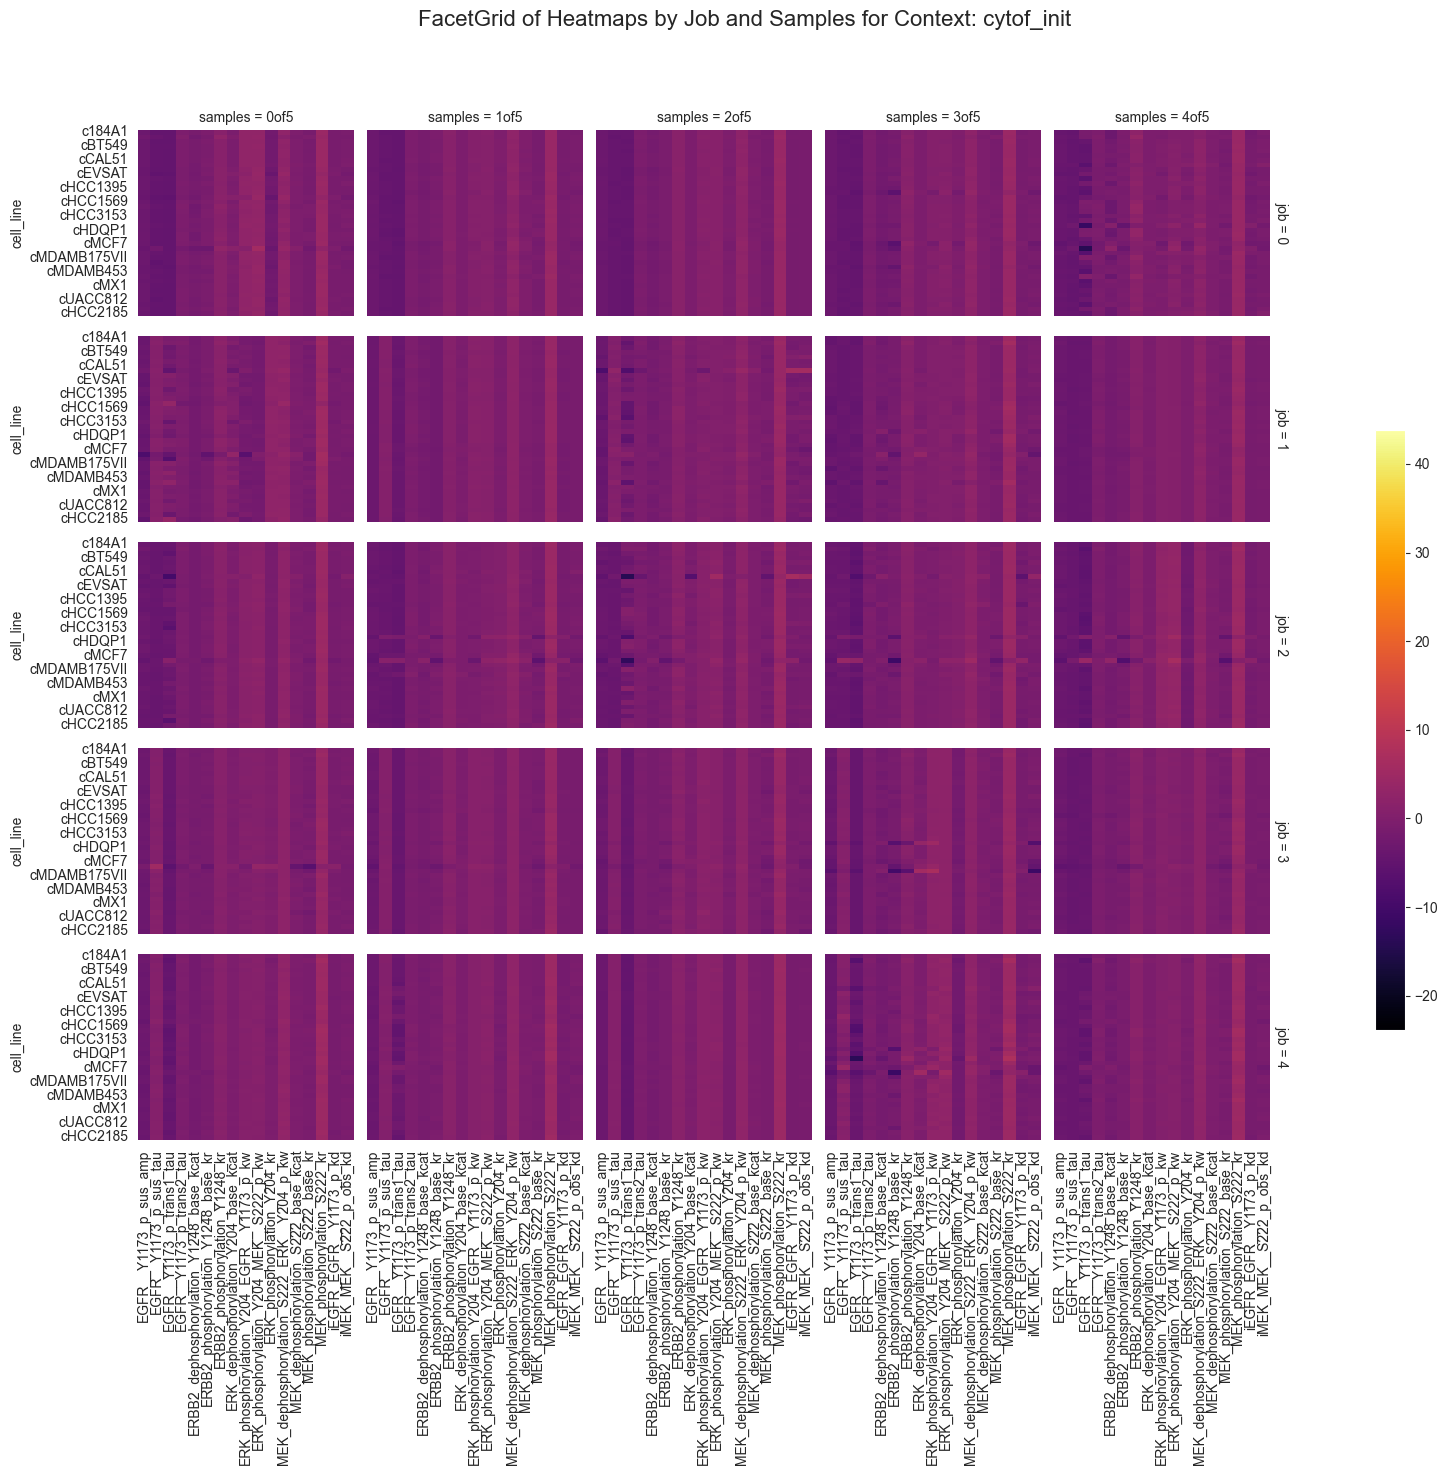

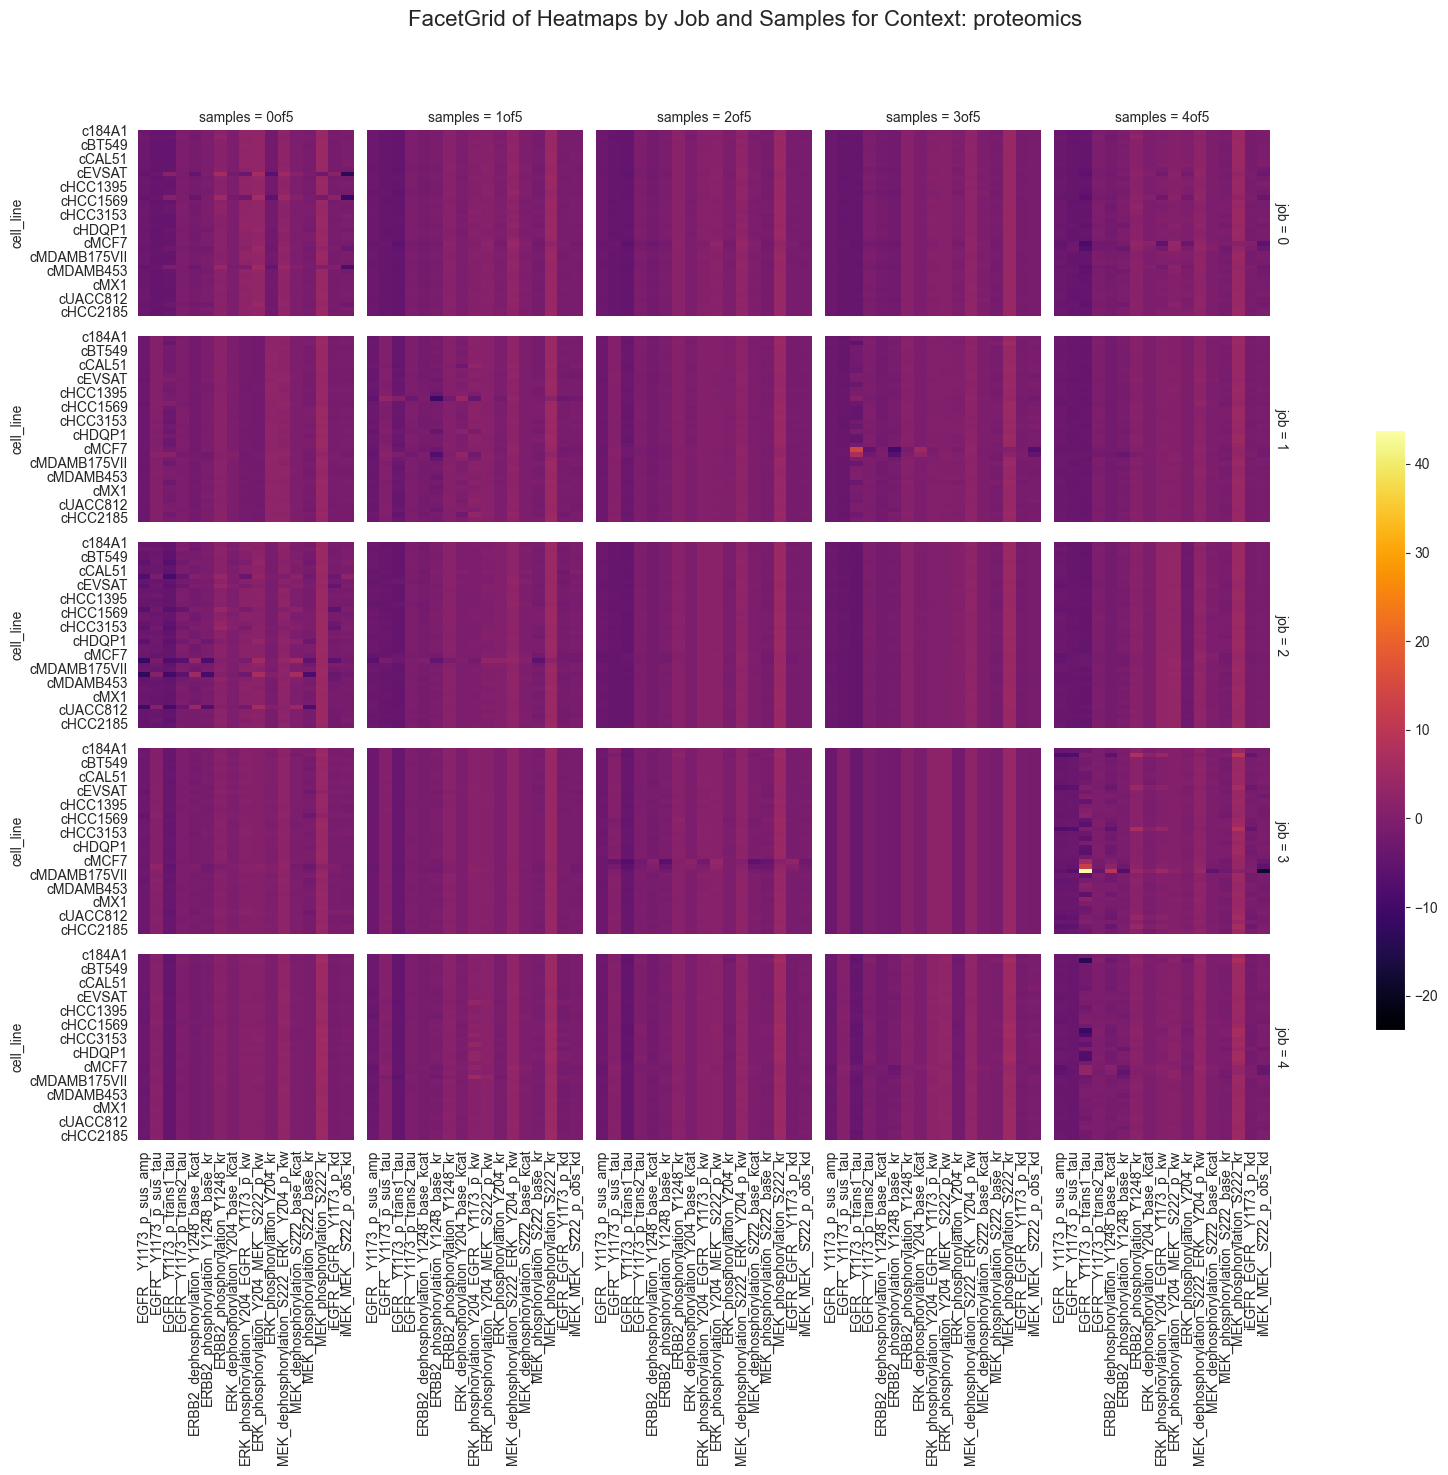

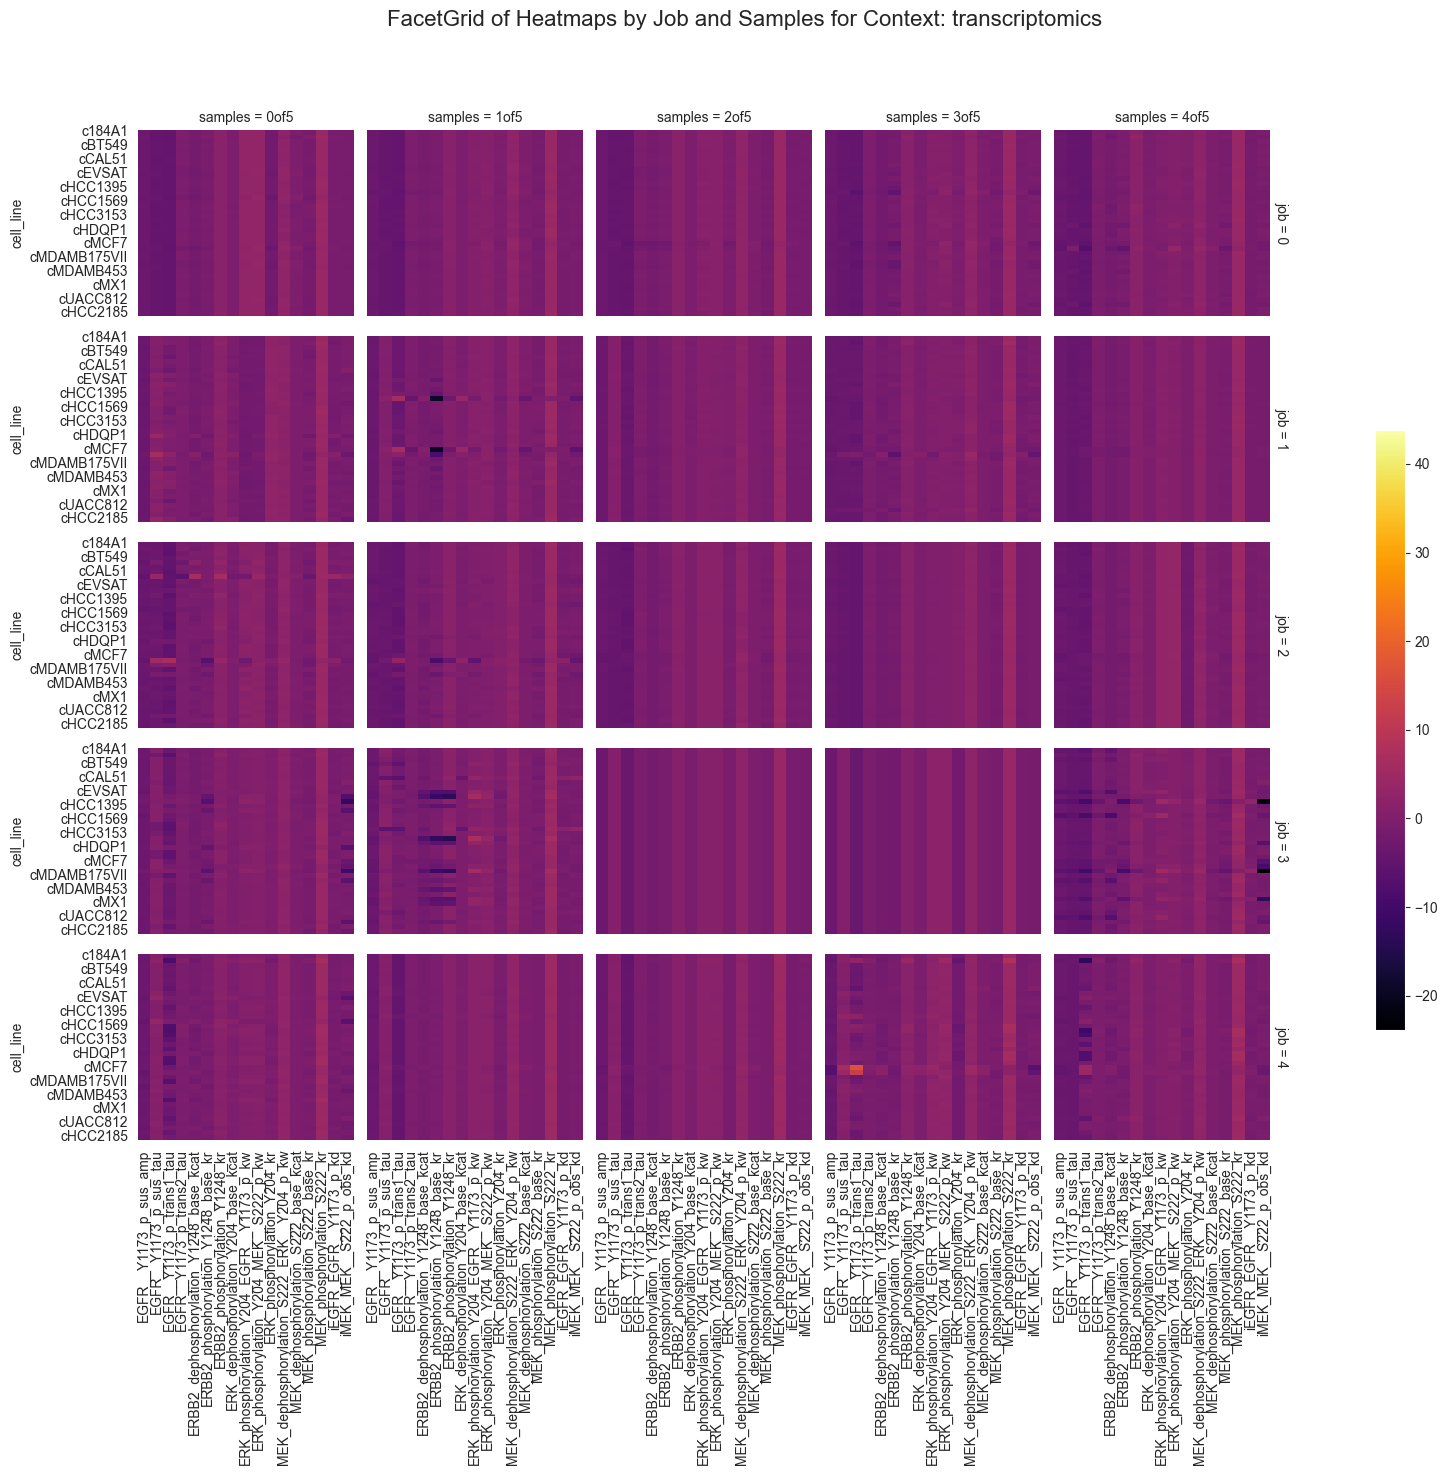

In [63]:
params_df = pd.read_csv(
    evaluations_dir / "EGFR_MAPK" / "dream_cytof" / "EGFR_MAPK.dream_cytof.parameters_full.csv", 
    index_col="cell_line"
).drop(columns=["Unnamed: 0"])

# Ensure parameter columns are numeric
parameter_columns = params_df.columns.difference(['samples', 'job', 'dataset', 'context', "subtype_PAM50", "subtype_Luminal/Basal"])

# Calculate the global vmin and vmax for the entire dataset (across all parameters)
vmin = params_df[parameter_columns].min().min()  # Minimum value across all parameters
vmax = params_df[parameter_columns].max().max()  # Maximum value across all parameters

# Define a function to plot a heatmap for each facet
def heatmap(data, **kwargs):
    sns.heatmap(data[parameter_columns], vmin=vmin, vmax=vmax, cbar=False, **kwargs)

# Loop through each unique context
for context in CONTEXT_SET:
    # Filter the dataframe for the current context
    params_df_context = params_df[params_df['context'] == context]
    
    # Create a FacetGrid for the current context
    g = sns.FacetGrid(params_df_context, col='samples', row='job', margin_titles=True)

    # Map the heatmap function onto the grid
    g.map_dataframe(heatmap, annot=False, cmap='inferno')

    # Add a single colorbar for the entire grid
    cbar_ax = g.fig.add_axes([.92, .3, .02, .4])  # Define the colorbar axis
    norm = plt.Normalize(vmin=vmin, vmax=vmax)  # Normalize the colorbar to the vmin and vmax
    sm = plt.cm.ScalarMappable(cmap="inferno", norm=norm)
    sm.set_array([])  # This step is necessary to set the scalar mappable correctly
    g.fig.colorbar(sm, cax=cbar_ax)  # Add the colorbar to the grid

    # Adjust layout and add a title indicating the context
    plt.subplots_adjust(top=0.9, right=0.85)  # Adjust the right side to fit the colorbar
    g.fig.suptitle(f'FacetGrid of Heatmaps by Job and Samples for Context: {context}', fontsize=16)

    # Show the plots
    plt.show()